# Precipitation-Feature (PF) Database — Overview

TRMM + GPM Radar Precipitation Features built into `/data/scratch/a/snesbitt/pf_db`
(Nesbitt-style RPFs, current permissive definition: 1-pixel minimum, per-instrument
noise-floor threshold). This notebook reads the consolidated **DuckDB catalog** (`pf_catalog.duckdb`, one
parquet per mission/year) instead of opening 150k+ per-orbit files** and produces:

1. PF frequency on a **0.5° grid** (TRMM and GPM).
2. Maps of the **top-10 max 40-dBZ heights** and **10 lowest 85/89-GHz PCTs** per mission.
3. A **land / ocean / coastline** summary table.
4. **PDFs** of max 40-dBZ height and 85/89-GHz PCT for each surface population, per sensor.

> Re-run any time: it snapshots whatever orbits are on disk, so it tracks the build as it grows.

In [1]:
import warnings
import numpy as np, pandas as pd
import duckdb
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
try:
    import cartopy.crs as ccrs, cartopy.feature as cfeature
    HAVE_CARTOPY = True
except Exception:
    HAVE_CARTOPY = False
print("cartopy:", HAVE_CARTOPY)

PF_ROOT = "/data/scratch/a/snesbitt/pf_db"
CATALOG = f"{PF_ROOT}/pf_catalog.duckdb"     # consolidated DuckDB "superdatabase"
GRID_DEG = 0.25

# One read-only connection; views `features`, `pixels`, `era5` are backed by the
# consolidated per-(mission,year) parquet under {PF_ROOT}/consolidated/.
con = duckdb.connect(CATALOG, read_only=True)
con.execute("PRAGMA threads=16")
print("catalog views:", [r[0] for r in con.execute("SHOW TABLES").fetchall()])

cartopy: True
catalog views: ['era5', 'features', 'pixels']


## Load all processed feature files

In [2]:
# No full-table pull. Every analysis below is an AGGREGATION pushed into DuckDB,
# so we transfer KB, not the ~12 GB of 158M x 9 columns. Helpers + shared SQL:
def q(sql, *params):
    return con.execute(sql, list(params)).df()

# ocean if ocean-fraction dominates, land if land dominates, else coast (margin).
POP = ("CASE WHEN frac_ocean >= 0.5 THEN 'ocean' "
       "WHEN frac_land >= 0.5 THEN 'land' ELSE 'coast' END")
MEMBERS = [m for (m,) in con.execute(
    "SELECT DISTINCT mission FROM features ORDER BY mission").fetchall()]

# Summary counts (each is a tiny GROUP BY over the columnar store).
ntot = con.execute("SELECT count(*) FROM features").fetchone()[0]
print(f"{ntot:,} features  |  by mission:")
print(q("SELECT mission, count(*) AS n FROM features GROUP BY 1 ORDER BY 1")
        .to_string(index=False))
print("\nby population:")
print(q(f"SELECT {POP} AS population, count(*) AS n FROM features "
        "GROUP BY 1 ORDER BY 2 DESC").to_string(index=False))

157,756,122 features  |  by mission:


mission        n
    GPM 67407029
   TRMM 90349093

by population:


population         n
     ocean 132087642
      land  24672958
     coast    995522


## 0 — PF inventory by month (data-gap check)

PF counts per calendar month for each mission, straight from the consolidated
catalog. Months that are **absent** within a mission's span, or anomalously low,
flag ingest/archive gaps — e.g. the TRMM PR boost-down gap (no data
2014-11 → 2015-01). Year/month are taken from each feature's mean `time`.

GPM: 146 months present  2014-03..2026-04  median=480,751 PFs/mo
   MISSING months : none
   LOW (<20% med) : 2024-04, 2026-02, 2026-04

TRMM: 198 months present  1997-12..2014-10  median=467,600 PFs/mo
   MISSING months : 2012-12, 2013-01, 2013-02, 2013-03, 2013-04
   LOW (<20% med) : 1999-10, 2012-11, 2014-03, 2014-05



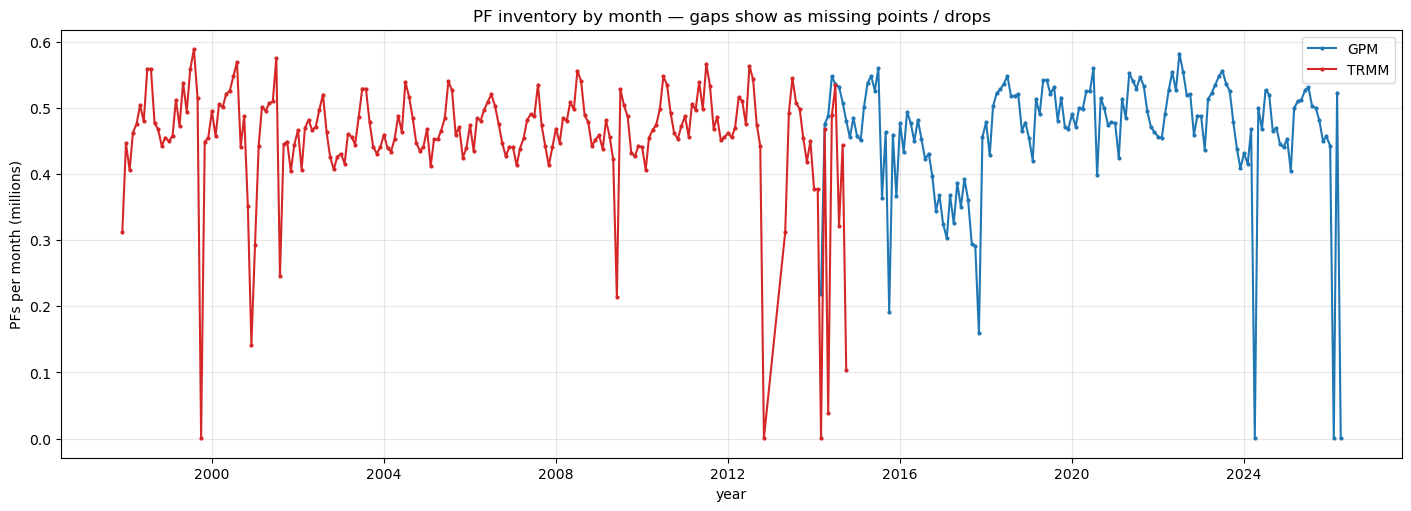

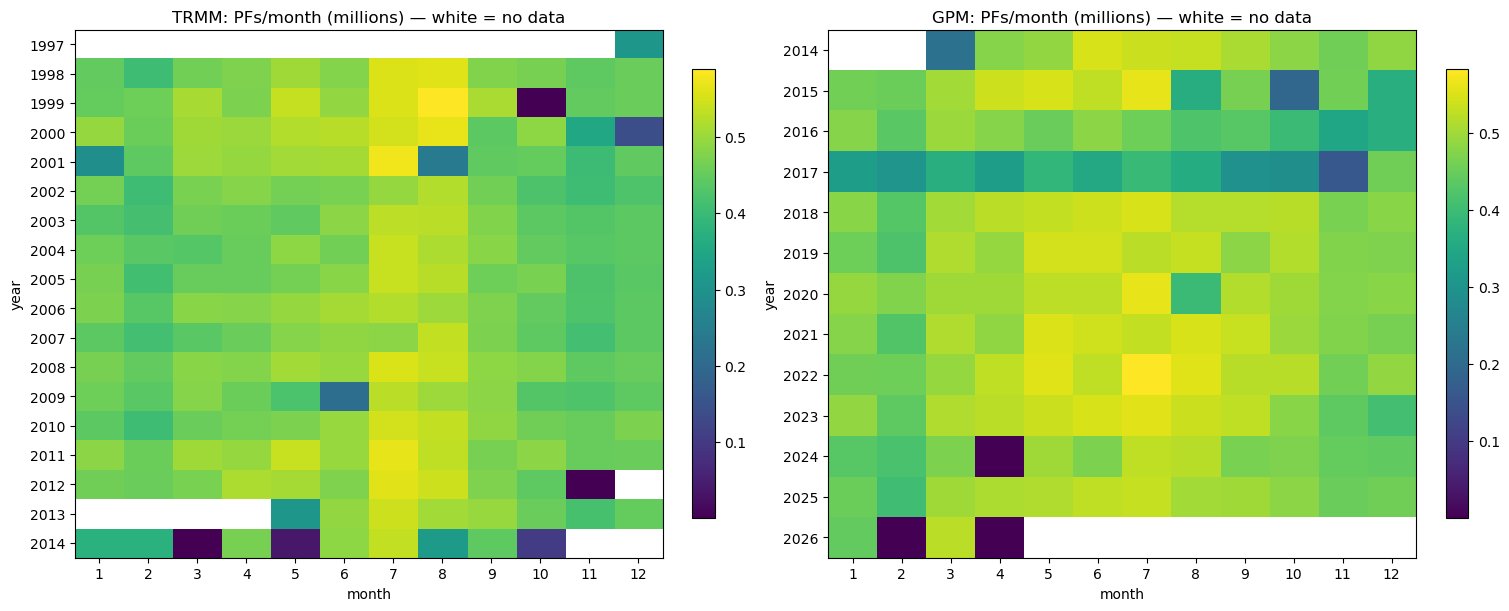

In [3]:
inv = con.execute("""
    SELECT mission, CAST(year(time) AS INT) AS yr, CAST(month(time) AS INT) AS mo,
           count(*) AS n_pfs
    FROM features
    GROUP BY 1, 2, 3
    ORDER BY 1, 2, 3
""").df()
inv["date"] = pd.to_datetime(dict(year=inv.yr, month=inv.mo, day=1))

# explicit missing / low-count month report per mission
for m, g in inv.groupby("mission"):
    present = set(zip(g.yr, g.mo))
    lo, hi = g.date.min(), g.date.max()
    full = pd.period_range(lo, hi, freq="M")
    missing = [(p.year, p.month) for p in full if (p.year, p.month) not in present]
    med = g.n_pfs.median()
    low = g[g.n_pfs < 0.2 * med]
    print(f"{m}: {len(g)} months present  {lo:%Y-%m}..{hi:%Y-%m}  median={med:,.0f} PFs/mo")
    print(f"   MISSING months : {', '.join(f'{y}-{mo:02d}' for y, mo in missing) or 'none'}")
    print(f"   LOW (<20% med) : {', '.join(f'{int(r.yr)}-{int(r.mo):02d}' for _, r in low.iterrows()) or 'none'}\n")

# (a) monthly time series
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
col = {"TRMM": "tab:red", "GPM": "tab:blue"}
for m, g in inv.groupby("mission"):
    g = g.sort_values("date")
    ax.plot(g.date, g.n_pfs / 1e6, ".-", ms=4, color=col[m], label=m)
ax.set_xlabel("year"); ax.set_ylabel("PFs per month (millions)")
ax.set_title("PF inventory by month — gaps show as missing points / drops")
ax.grid(alpha=0.3); ax.legend()
plt.show()

# (b) year x month heatmaps (white = no data) make gaps obvious
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
for ax, m in zip(axes, ["TRMM", "GPM"]):
    g = inv[inv.mission == m]
    years = list(range(int(g.yr.min()), int(g.yr.max()) + 1))
    M = np.full((len(years), 12), np.nan)
    for _, r in g.iterrows():
        M[years.index(int(r.yr)), int(r.mo) - 1] = r.n_pfs / 1e6
    Mm = np.ma.masked_invalid(M)
    cmap = plt.cm.viridis.copy(); cmap.set_bad("white")
    im = ax.imshow(Mm, aspect="auto", cmap=cmap)
    ax.set_xticks(range(12)); ax.set_xticklabels(range(1, 13)); ax.set_xlabel("month")
    ax.set_yticks(range(len(years))); ax.set_yticklabels(years); ax.set_ylabel("year")
    ax.set_title(f"{m}: PFs/month (millions) — white = no data")
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()

## 1 — PF frequency on a 0.5° grid

Counts of PF centroids per 0.5°×0.5° box, log-scaled (each mission on its own swath-limited latitude band).

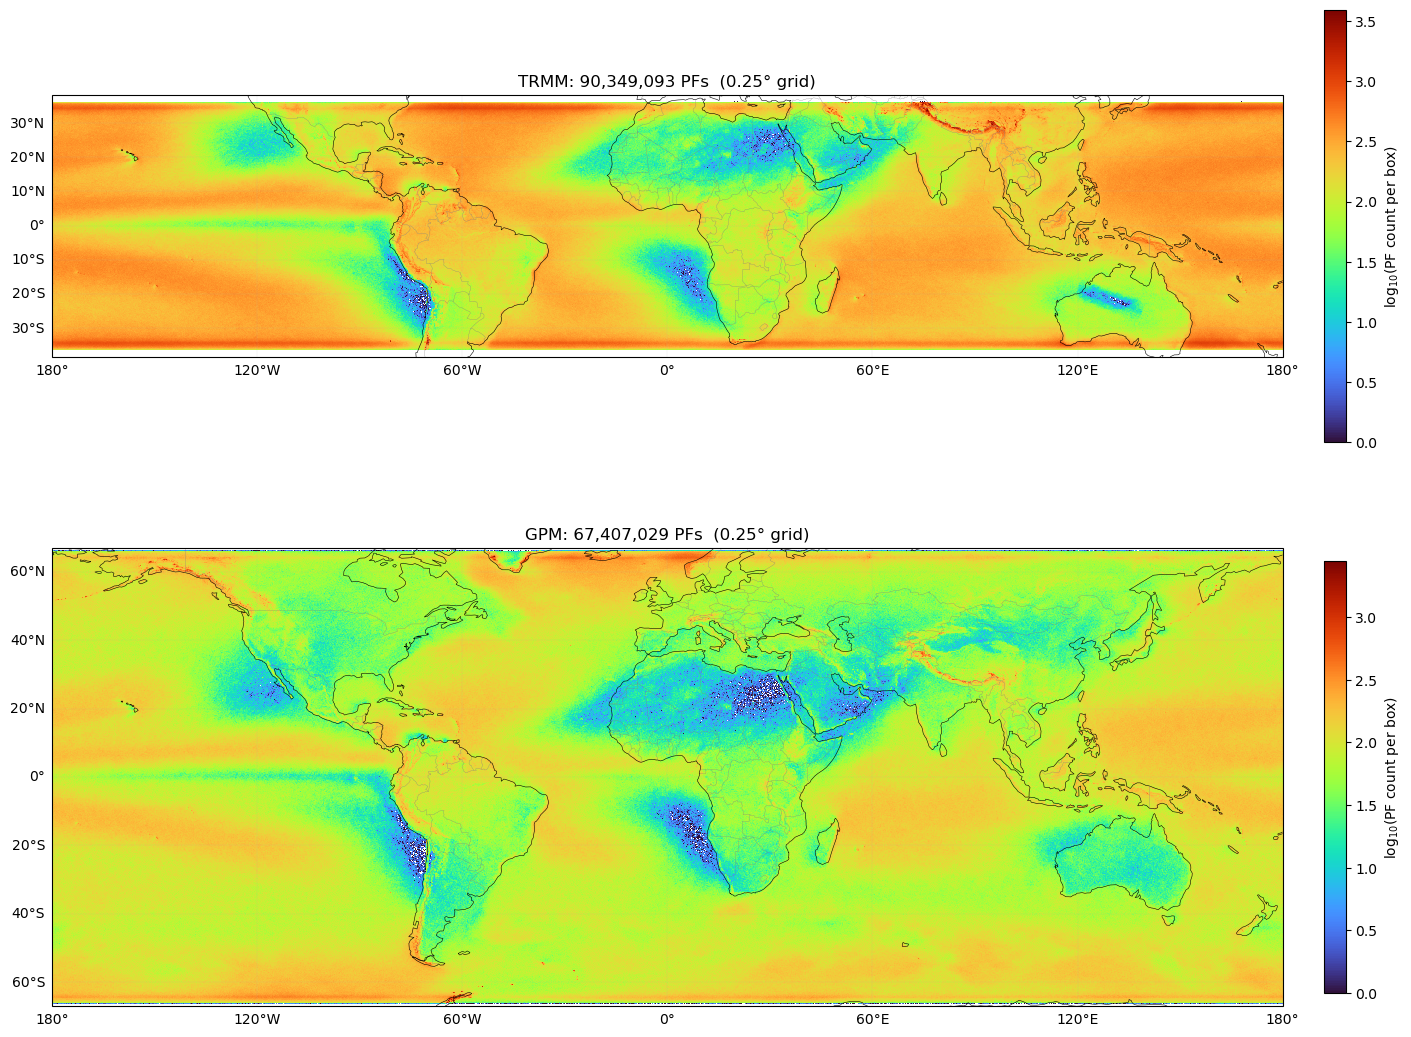

In [4]:
# 0.5deg (GRID_DEG) PF-centroid counts per box, binned IN DuckDB (returns only
# populated cells, ~10^4 rows) instead of np.histogram2d over 158M rows.
LON_EDGES = np.arange(-180, 180 + GRID_DEG, GRID_DEG)
LAT_EDGES = np.arange(-90, 90 + GRID_DEG, GRID_DEG)
nlon, nlat = len(LON_EDGES) - 1, len(LAT_EDGES) - 1

def grid_counts(mission):
    g = q(f"""
        SELECT CAST(floor((centroid_lon - (-180)) / {GRID_DEG}) AS INT) AS ix,
               CAST(floor((centroid_lat - (-90))  / {GRID_DEG}) AS INT) AS iy,
               count(*) AS n
        FROM features
        WHERE mission = ? AND centroid_lon >= -180 AND centroid_lon < 180
          AND centroid_lat >= -90 AND centroid_lat < 90
        GROUP BY 1, 2
    """, mission)
    H = np.zeros((nlat, nlon))
    # clip the top-edge bin (a centroid just under +180/+90 can floor to nlon/nlat
    # from float rounding) into the last cell, as np.histogram2d does; add (not
    # assign) so a merged edge bin is summed, never overwritten.
    iy = np.clip(g.iy.to_numpy(), 0, nlat - 1)
    ix = np.clip(g.ix.to_numpy(), 0, nlon - 1)
    np.add.at(H, (iy, ix), g.n.to_numpy())
    return H

proj = dict(projection=ccrs.PlateCarree()) if HAVE_CARTOPY else {}
fig, axes = plt.subplots(2, 1, figsize=(14, 11), subplot_kw=proj,
                         constrained_layout=True)
for ax, mission in zip(axes, ["TRMM", "GPM"]):
    H = grid_counts(mission)
    Hm = np.ma.masked_equal(H, 0)
    band = q("SELECT min(centroid_lat) lo, max(centroid_lat) hi, count(*) n "
             "FROM features WHERE mission = ?", mission).iloc[0]
    pcm = ax.pcolormesh(LON_EDGES, LAT_EDGES, np.log10(Hm), cmap="turbo",
                        shading="auto",
                        transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)
    if HAVE_CARTOPY:
        ax.coastlines(linewidth=0.4, color="k")
        ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="grey")
        gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.4)
        gl.top_labels = gl.right_labels = False
        ax.set_ylim(max(-67, band.lo - 2), min(67, band.hi + 2))
    else:
        ax.set_xlabel("lon"); ax.set_ylabel("lat")
    cb = fig.colorbar(pcm, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label("log$_{10}$(PF count per box)")
    ax.set_title(f"{mission}: {int(band.n):,} PFs  ({GRID_DEG}\u00b0 grid)")
plt.show()

## 1b — Longitude profile of PF counts near 100°W

A 1°-binned, **linear-count** slice from −105° to −95°E. The 0.5° map above is
`log10`-scaled, which visually exaggerates the apparent "dip" near 100°W. In
linear counts it is a broad, shallow (~25–30 %) minimum — the eastern-Pacific
subsidence zone offshore and the 100th-meridian humid/arid divide over North
America — **not** a binning or PF-algorithm artifact (it varies smoothly with
latitude and appears over both ocean and land).

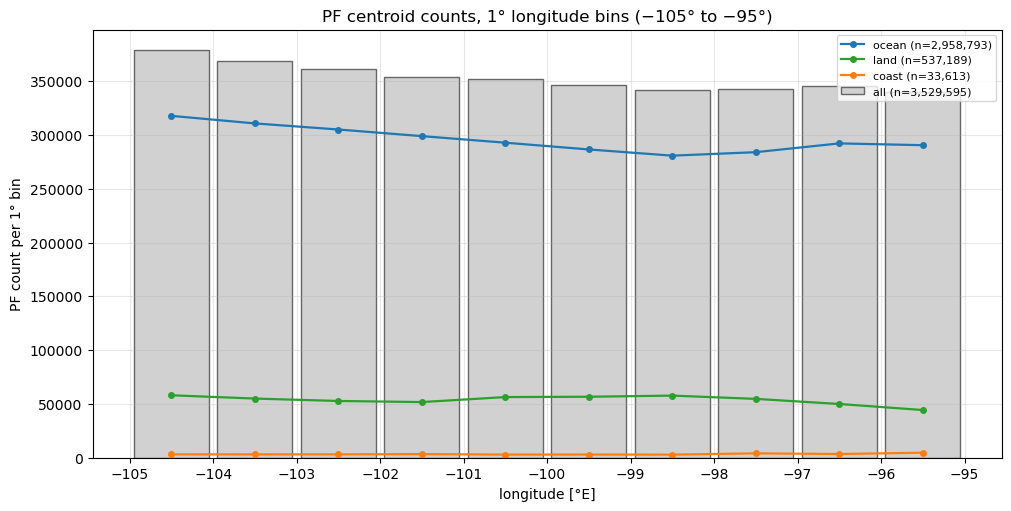

In [5]:
# 1deg longitude profile (-105..-95) by surface population, counted IN DuckDB.
lon_edges = np.arange(-105, -95 + 1, 1.0)
centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
prof = q(f"""
    SELECT CAST(floor(centroid_lon) AS INT) AS lon_bin, {POP} AS pop, count(*) AS n
    FROM features
    WHERE centroid_lon >= -105 AND centroid_lon < -95
    GROUP BY 1, 2
""")

def series(pop=None):
    s = prof if pop is None else prof[prof["pop"] == pop]
    h = s.groupby("lon_bin")["n"].sum()
    return np.array([int(h.get(int(c - 0.5), 0)) for c in centers])

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
tot = series()
ax.bar(centers, tot, width=0.9, color="0.82", edgecolor="0.4",
       label=f"all (n={tot.sum():,})", zorder=1)
for p, c in [("ocean", "tab:blue"), ("land", "tab:green"), ("coast", "tab:orange")]:
    h = series(p)
    ax.plot(centers, h, "-o", ms=4, lw=1.6, color=c,
            label=f"{p} (n={h.sum():,})", zorder=2)
ax.set_xlabel("longitude [\u00b0E]"); ax.set_ylabel("PF count per 1\u00b0 bin")
ax.set_xticks(np.arange(-105, -94, 1))
ax.set_title("PF centroid counts, 1\u00b0 longitude bins (\u2212105\u00b0 to \u221295\u00b0)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

## 2 — Extremes: top-10 deepest 40-dBZ echoes & 10 lowest PCTs

Most intense convection by two independent metrics: the **highest 40-dBZ echo top**
(radar intensity / updraft proxy) and the **lowest 85/89-GHz PCT** (large-ice scattering).

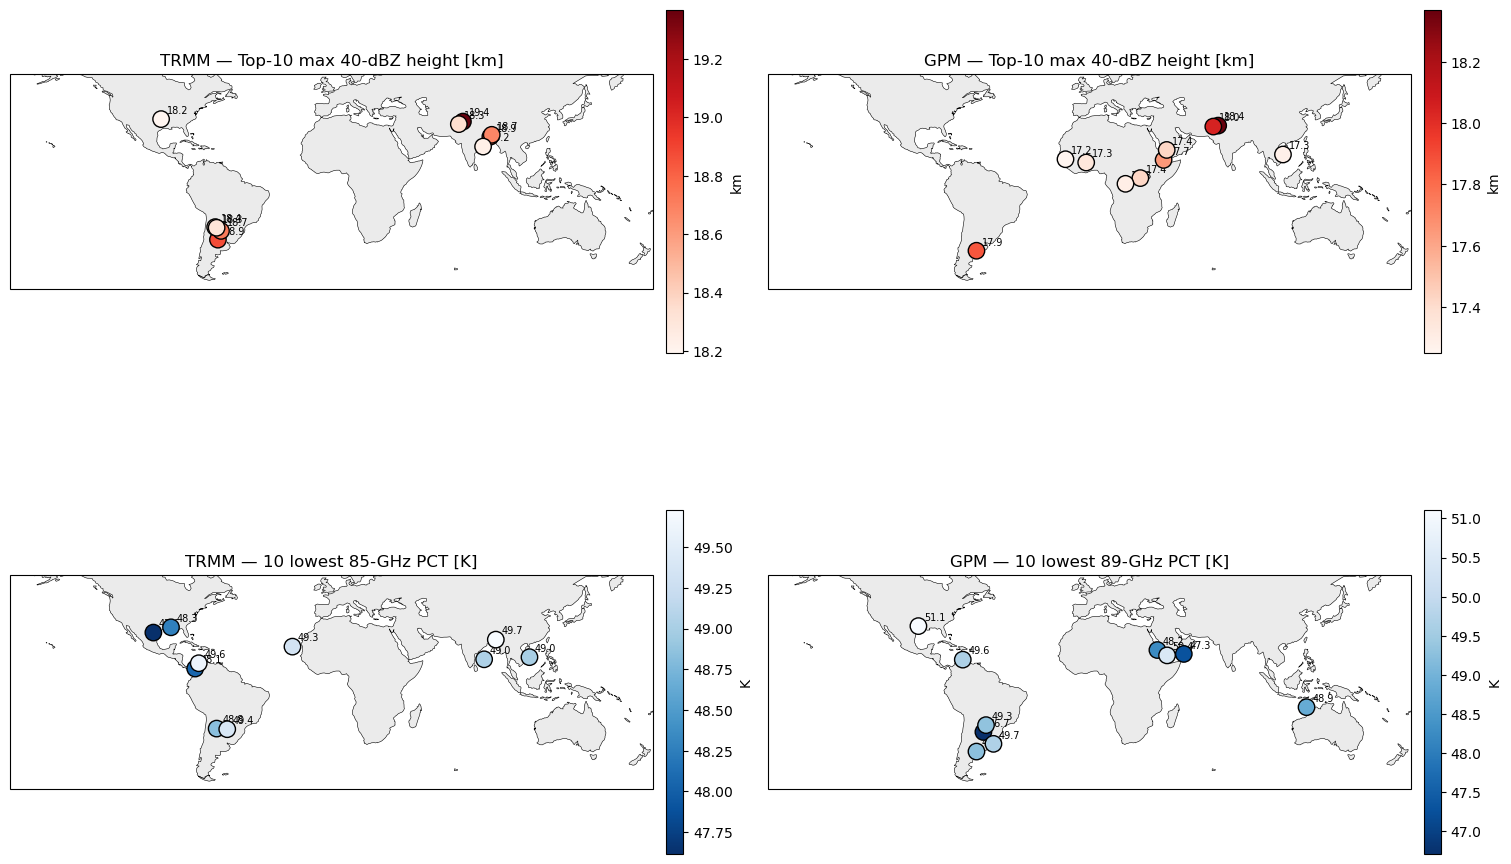


=== TRMM: top-10 deepest 40-dBZ ===
 centroid_lat  centroid_lon   ht40_km  min_pct_85_89 population
    33.473331     73.531250 19.368500      84.637360       land
   -32.627102    -63.598148 18.868183      57.044640       land
    25.030991     88.890411 18.861217            NaN       land
   -27.723635    -61.885265 18.722775      53.205639       land
    26.070824     89.660774 18.676550      65.982941       land
   -25.602430    -65.160286 18.350273      87.588402       land
    32.043598     71.239372 18.345779      51.520580       land
   -25.962339    -64.339478 18.310743      48.827038       land
    19.480215     84.818016 18.229263      68.228935       land
    34.860390    -95.425262 18.192337      53.021313       land

=== TRMM: 10 lowest PCT ===


 centroid_lat  centroid_lon  min_pct_85_89   ht40_km population
    27.777140    -99.746071      47.616180 16.137314       land
     7.641851    -76.339699      48.057777 16.263760       land
    30.723976    -89.876877      48.266441 16.263874       land
   -25.962339    -64.339478      48.827038 18.310743       land
    14.020794    110.782204      48.996540 13.706902      ocean
    12.820086     85.405502      49.038815 14.226278      ocean
    19.915440    -21.882868      49.332718 14.994624      ocean
   -26.307379    -58.395866      49.391052 14.427076       land
    10.625910    -74.350517      49.615059 16.590830       land
    23.834557     91.944214      49.724815 17.100813       land

=== GPM: top-10 deepest 40-dBZ ===
 centroid_lat  centroid_lon   ht40_km  min_pct_85_89 population
    31.217918     72.125259 18.371431      54.944321       land
    30.680374     69.393379 18.048996      66.829147       land
   -38.825443    -63.180187 17.868273      49.253433       land
    

 centroid_lat  centroid_lon  min_pct_85_89   ht40_km population
   -27.853714    -59.298748      46.711597 16.945107       land
    15.826472     52.884972      47.284157 14.908204      ocean
    18.013044     38.102036      48.245232 14.887771       land
   -13.986994    121.583893      48.851597 12.919162      ocean
   -38.825443    -63.180187      49.253433 17.868273       land
   -24.018110    -57.835945      49.309757 14.726275       land
    12.634608    -70.837067      49.649673 14.004663      ocean
   -34.510853    -53.666958      49.694256 13.606672      ocean
    15.013865     43.508160      50.446152 14.957210       land
    31.408228    -95.679596      51.101635 16.201611       land


In [6]:
# Extremes via ORDER BY ... LIMIT 10 in DuckDB (10 rows each, no full pull).
def topn(mission, col, largest=True):
    order = "DESC" if largest else "ASC"
    return q(f"""
        SELECT centroid_lat, centroid_lon,
               max_ht_40dbz/1000.0 AS ht40_km, min_pct_85_89, {POP} AS population
        FROM features
        WHERE mission = ? AND {col} IS NOT NULL AND isfinite({col})
        ORDER BY {col} {order} LIMIT 10
    """, mission)

specs = [("TRMM", "max_ht_40dbz", True,  "Top-10 max 40-dBZ height [km]", "Reds", "ht40_km"),
         ("GPM",  "max_ht_40dbz", True,  "Top-10 max 40-dBZ height [km]", "Reds", "ht40_km"),
         ("TRMM", "min_pct_85_89", False, "10 lowest 85-GHz PCT [K]", "Blues_r", "min_pct_85_89"),
         ("GPM",  "min_pct_85_89", False, "10 lowest 89-GHz PCT [K]", "Blues_r", "min_pct_85_89")]
proj = dict(projection=ccrs.PlateCarree()) if HAVE_CARTOPY else {}
fig, axes = plt.subplots(2, 2, figsize=(15, 10), subplot_kw=proj, constrained_layout=True)
for ax, (mission, col, largest, label, cmap, plotcol) in zip(axes.ravel(), specs):
    ext = topn(mission, col, largest)
    if HAVE_CARTOPY:
        ax.set_global(); ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.LAND, facecolor="0.92"); ax.set_ylim(-60, 60)
    sc = ax.scatter(ext["centroid_lon"], ext["centroid_lat"], c=ext[plotcol],
                    cmap=cmap, s=140, edgecolor="k", zorder=5,
                    transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)
    for _, r in ext.iterrows():
        ax.annotate(f"{r[plotcol]:.1f}", (r["centroid_lon"], r["centroid_lat"]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points",
                    transform=ccrs.PlateCarree() if HAVE_CARTOPY else ax.transData)
    fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02, label=label.split("[")[-1].rstrip("]"))
    ax.set_title(f"{mission} \u2014 {label}")
plt.show()

for mission in ["TRMM", "GPM"]:
    print(f"\n=== {mission}: top-10 deepest 40-dBZ ===")
    print(topn(mission, "max_ht_40dbz", True)[
        ["centroid_lat","centroid_lon","ht40_km","min_pct_85_89","population"]].to_string(index=False))
    print(f"\n=== {mission}: 10 lowest PCT ===")
    print(topn(mission, "min_pct_85_89", False)[
        ["centroid_lat","centroid_lon","min_pct_85_89","ht40_km","population"]].to_string(index=False))

## 3 — PF counts by surface population

In [7]:
# Population counts straight from a GROUP BY (6 rows).
g = q(f"SELECT mission, {POP} AS population, count(*) AS n_PFs FROM features GROUP BY 1,2")
tab = g.pivot(index="mission", columns="population", values="n_PFs").reindex(
    columns=["land", "ocean", "coast"]).fillna(0).astype(int)
tab["total"] = tab.sum(axis=1)
pct = tab[["land","ocean","coast"]].div(tab["total"], axis=0) * 100
summary = tab.copy()
for c in ["land","ocean","coast"]:
    summary[c] = tab[c].map("{:,.0f}".format) + " (" + pct[c].map("{:.1f}%".format) + ")"
summary["total"] = tab["total"].map("{:,.0f}".format)
print("PFs by surface population (count and % of mission):\n")
print(summary.to_string())
summary

PFs by surface population (count and % of mission):

population                land               ocean           coast       total
mission                                                                       
GPM         11,102,368 (16.5%)  55,699,199 (82.6%)  605,462 (0.9%)  67,407,029
TRMM        13,570,590 (15.0%)  76,388,443 (84.5%)  390,060 (0.4%)  90,349,093


population,land,ocean,coast,total
mission,,,,
GPM,"11,102,368 (16.5%)","55,699,199 (82.6%)","605,462 (0.9%)","67,407,029"
TRMM,"13,570,590 (15.0%)","76,388,443 (84.5%)","390,060 (0.4%)","90,349,093"


## 4 — Distributions by population and sensor

PDFs (density-normalized histograms) of **max 40-dBZ height** and **85/89-GHz PCT**,
split by surface population, for each sensor.

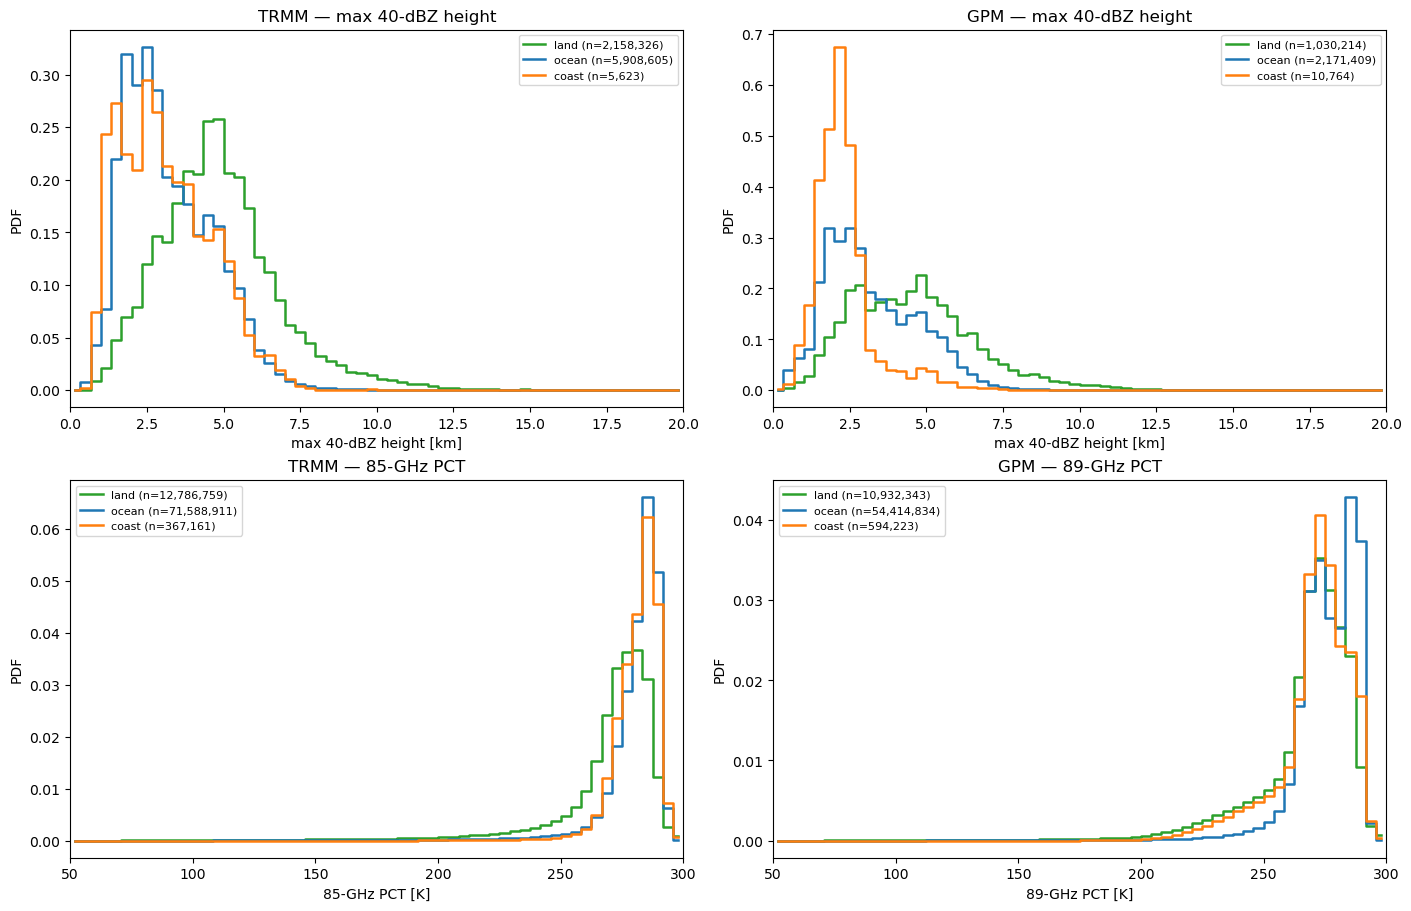

In [8]:
# Density histograms with bin COUNTS computed in DuckDB (≈60 rows/panel), then
# normalized to a PDF in pandas — no per-feature array pulled.
colors = {"land": "tab:green", "ocean": "tab:blue", "coast": "tab:orange"}
panels = [("TRMM", "max_ht_40dbz/1000.0", "max 40-dBZ height [km]", 0.0, 20.0, 60, True),
          ("GPM",  "max_ht_40dbz/1000.0", "max 40-dBZ height [km]", 0.0, 20.0, 60, True),
          ("TRMM", "min_pct_85_89", "85-GHz PCT [K]", 50.0, 300.0, 60, False),
          ("GPM",  "min_pct_85_89", "89-GHz PCT [K]", 50.0, 300.0, 60, False)]

def hist(mission, expr, lo, hi, nb, pos_only):
    w = (hi - lo) / nb
    extra = f" AND {expr} > 0" if pos_only else ""
    g = q(f"""
        SELECT {POP} AS pop,
               LEAST(GREATEST(CAST(floor(({expr} - {lo})/{w}) AS INT), 0), {nb-1}) AS b,
               count(*) AS n
        FROM features
        WHERE mission = ? AND {expr} IS NOT NULL AND isfinite({expr})
              AND {expr} >= {lo} AND {expr} < {hi}{extra}
        GROUP BY 1, 2
    """, mission)
    return g, w

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for ax, (mission, expr, xlabel, lo, hi, nb, pos_only) in zip(axes.ravel(), panels):
    centers = lo + (np.arange(nb) + 0.5) * (hi - lo) / nb
    g, w = hist(mission, expr, lo, hi, nb, pos_only)
    for p in ["land", "ocean", "coast"]:
        s = g[g["pop"] == p]
        counts = np.zeros(nb)
        counts[s.b.to_numpy()] = s.n.to_numpy()
        ntot = counts.sum()
        if ntot > 10:
            ax.step(centers, counts / (ntot * w), where="mid", lw=1.8,
                    color=colors[p], label=f"{p} (n={int(ntot):,})")
    ax.set_xlabel(xlabel); ax.set_ylabel("PDF"); ax.set_xlim(lo, hi)
    ax.set_title(f"{mission} \u2014 {xlabel.split('[')[0].strip()}")
    ax.legend(fontsize=8)
plt.show()